In [1]:
import torch
import torch.nn as nn
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torch import optim

# For reproducability
torch.manual_seed(0)

In [2]:
class MNISTConvNet(nn.Module):
  def __init__(self):
    super(MNISTConvNet, self).__init__()
    self.conv1 = nn.Sequential(
        nn.Conv2d(1, 32, 5, padding='same'),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.conv2 = nn.Sequential(
        nn.Conv2d(32, 64, 5, padding='same'),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.fc1 = nn.Sequential(
        nn.Flatten(),
        nn.Linear(7*7*64, 1024),
        nn.Dropout(0.5),
        nn.Linear(1024, 10)
    )

  def forward(self, x):
    x = self.conv1(x)
    x = self.conv2(x)
    return self.fc1(x)

In [3]:
trainset = MNIST('.', train=True, download=True, 
                      transform=ToTensor())
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

In [ ]:
# Testing cpu training time
lr = 1e-4
num_epochs = 5

device = 'cpu'
model_nocuda = MNISTConvNet().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_nocuda.parameters(), lr=lr)

for epochs in range(num_epochs):
  running_loss = 0.0
  num_correct = 0
  for inputs, labels in trainloader:
    optimizer.zero_grad()
    outputs = model_nocuda(inputs.to(device))
    loss = loss_fn(outputs, labels.to(device))
    loss.backward()
    running_loss += loss.item()
    optimizer.step()
    _, idx = outputs.max(dim=1)
    num_correct += (idx == labels.to(device)).sum().item()
  print('Loss: {} Accuracy: {}'.format(running_loss/len(trainloader),
        num_correct/len(trainloader)))
  
  # ~60s per epoch on CPU

Loss: 2.3022636073484604 Accuracy: 6.330490405117271
Loss: 2.2964919096371257 Accuracy: 7.190831556503198
Loss: 2.2903462361171045 Accuracy: 8.465884861407249
Loss: 2.2843109486199644 Accuracy: 9.722814498933902
Loss: 2.2779305420958917 Accuracy: 11.480810234541577


In [7]:
lr = 1e-4
num_epochs = 40

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = MNISTConvNet().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr)

for epochs in range(num_epochs):
  running_loss = 0.0
  num_correct = 0
  for inputs, labels in trainloader:
    optimizer.zero_grad()
    outputs = model(inputs.to(device))
    loss = loss_fn(outputs, labels.to(device))
    loss.backward()
    running_loss += loss.item()
    optimizer.step()
    _, idx = outputs.max(dim=1)
    num_correct += (idx == labels.to(device)).sum().item()
  print('Loss: {} Accuracy: {}'.format(running_loss/len(trainloader),
        num_correct/len(trainloader)))
  
  # ~13s per epoch w/ CUDA

Loss: 2.3006509959316457 Accuracy: 7.546908315565032
Loss: 2.2925050573816685 Accuracy: 9.491471215351812
Loss: 2.28419596732044 Accuracy: 12.025586353944563
Loss: 2.2752782294490954 Accuracy: 14.587420042643924
Loss: 2.2656037693084685 Accuracy: 17.567164179104477
Loss: 2.2554513559158424 Accuracy: 20.440298507462686
Loss: 2.244080383386185 Accuracy: 23.256929637526653
Loss: 2.2309710267764418 Accuracy: 25.85820895522388
Loss: 2.2160551614090322 Accuracy: 28.204690831556505
Loss: 2.1989279520282867 Accuracy: 30.420042643923242
Loss: 2.1787718130327236 Accuracy: 32.50639658848614
Loss: 2.154390285772555 Accuracy: 34.91577825159915
Loss: 2.1259532907624235 Accuracy: 36.90405117270789
Loss: 2.092446292895498 Accuracy: 38.27825159914712
Loss: 2.04989110940555 Accuracy: 40.12153518123667
Loss: 1.9987164277003517 Accuracy: 41.3816631130064
Loss: 1.9364829818322968 Accuracy: 42.17484008528785
Loss: 1.86042612727517 Accuracy: 43.09808102345416
Loss: 1.7676222689116179 Accuracy: 43.97867803837

ACTUAL: 1
MODEL OUTPUT: 1


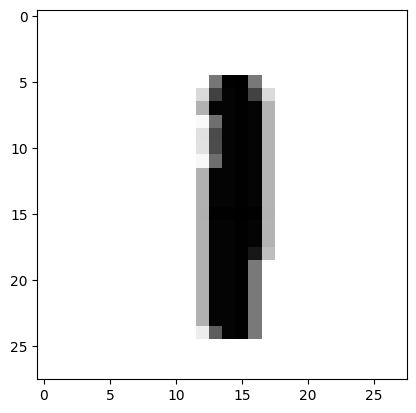

ACTUAL: 9
MODEL OUTPUT: 9


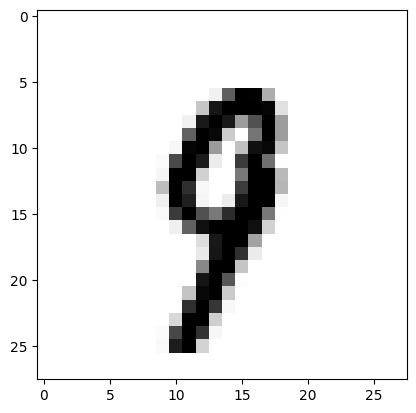

ACTUAL: 4
MODEL OUTPUT: 4


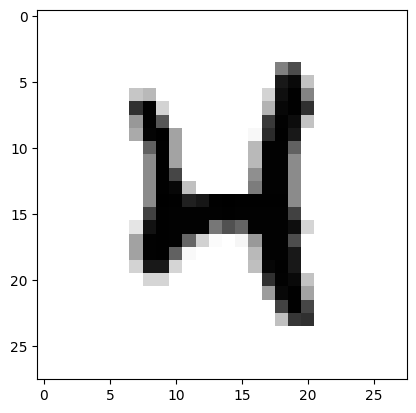

ACTUAL: 3
MODEL OUTPUT: 3


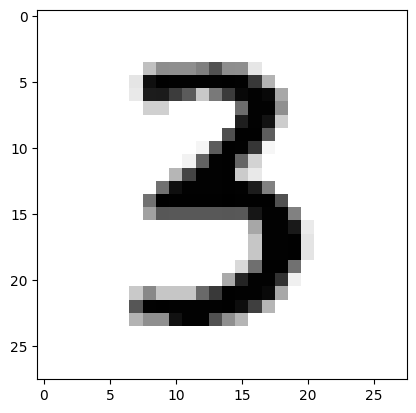

ACTUAL: 4
MODEL OUTPUT: 4


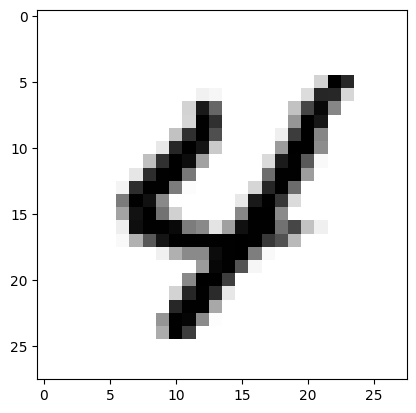

ACTUAL: 8
MODEL OUTPUT: 8


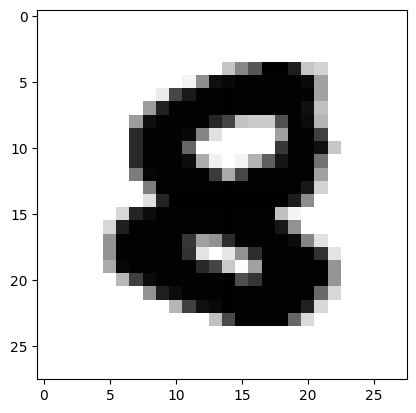

ACTUAL: 9
MODEL OUTPUT: 9


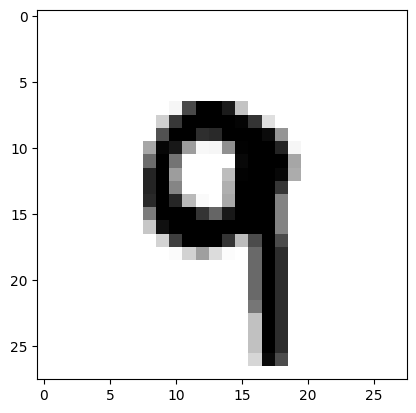

ACTUAL: 6
MODEL OUTPUT: 6


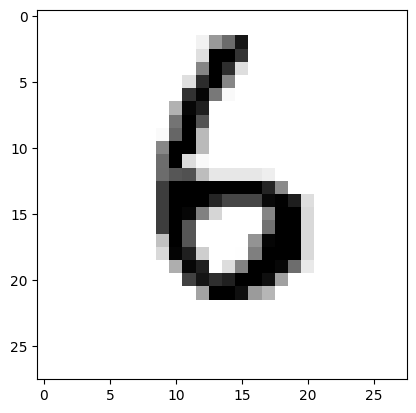

ACTUAL: 7
MODEL OUTPUT: 7


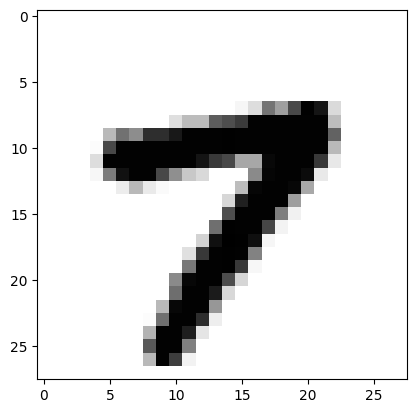

ACTUAL: 8
MODEL OUTPUT: 3


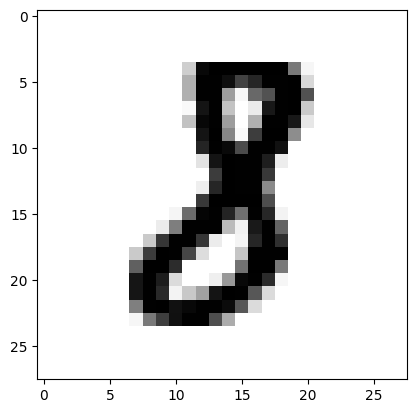

ACTUAL: 7
MODEL OUTPUT: 7


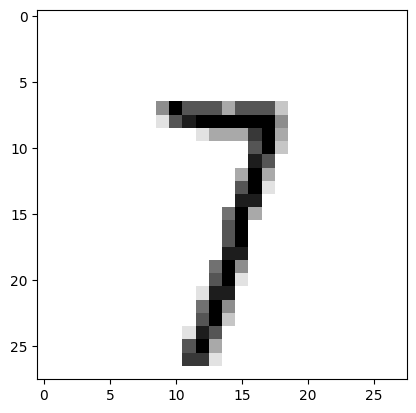

ACTUAL: 3
MODEL OUTPUT: 3


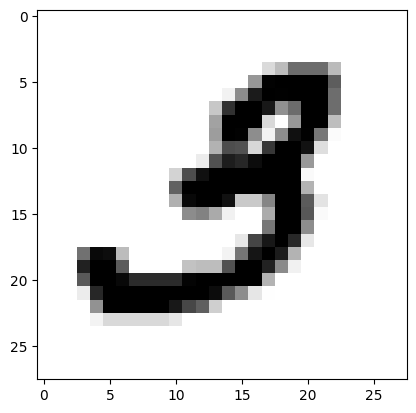

ACTUAL: 1
MODEL OUTPUT: 1


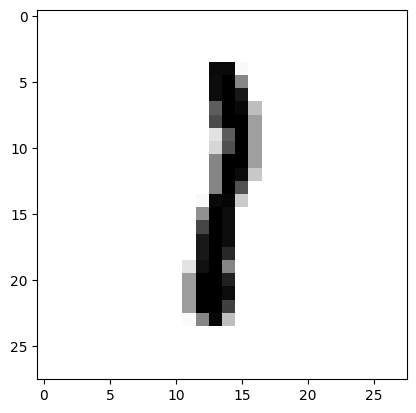

ACTUAL: 9
MODEL OUTPUT: 9


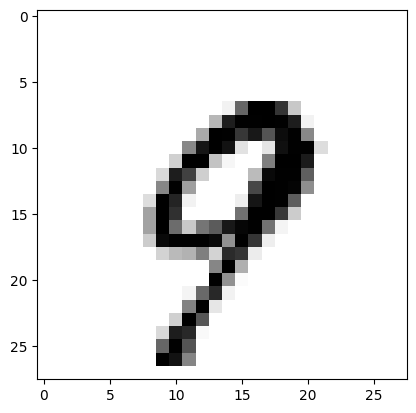

ACTUAL: 7
MODEL OUTPUT: 7


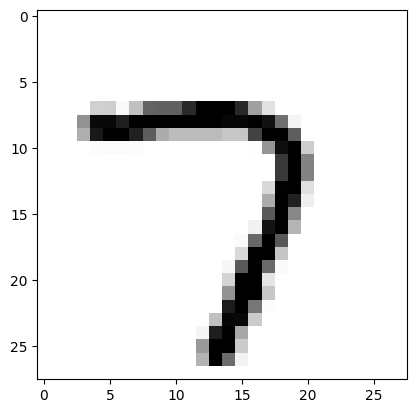

ACTUAL: 0
MODEL OUTPUT: 0


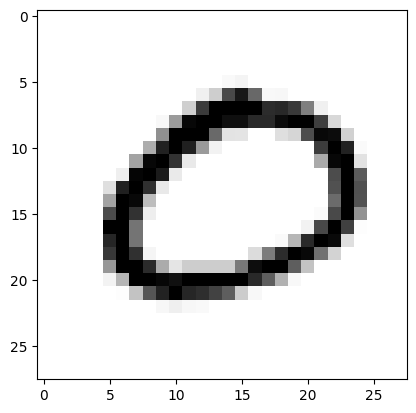

ACTUAL: 6
MODEL OUTPUT: 6


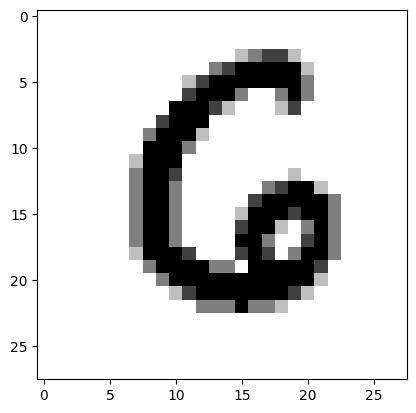

ACTUAL: 2
MODEL OUTPUT: 0


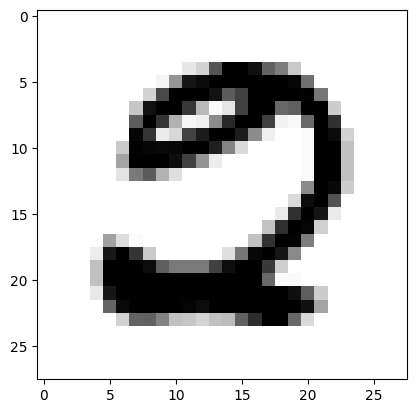

ACTUAL: 5
MODEL OUTPUT: 5


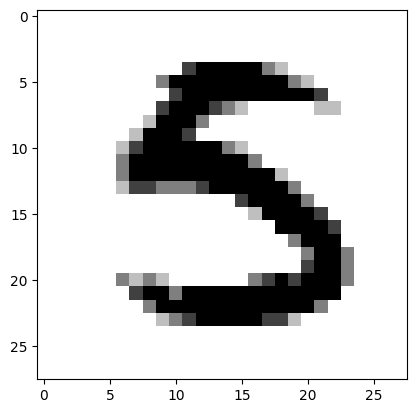

ACTUAL: 7
MODEL OUTPUT: 7


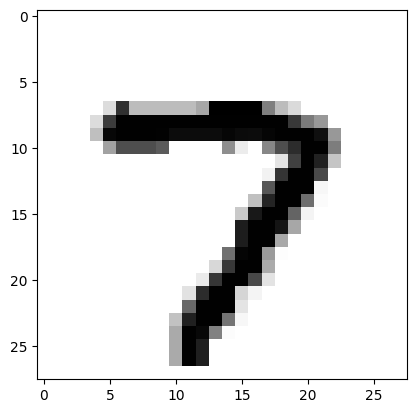

ACTUAL: 1
MODEL OUTPUT: 1


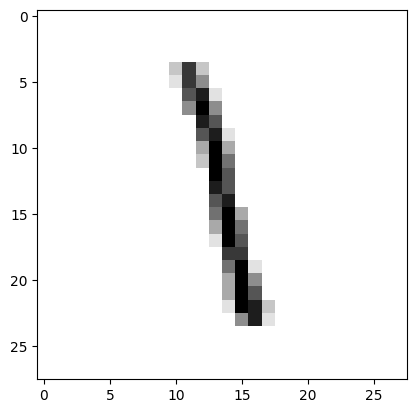

ACTUAL: 9
MODEL OUTPUT: 0


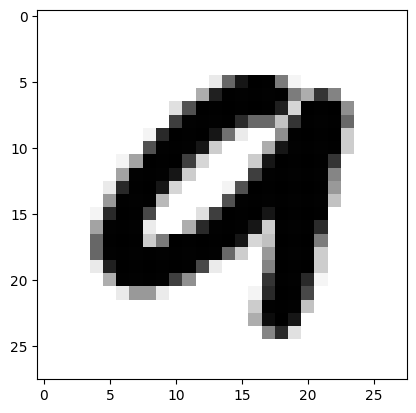

ACTUAL: 1
MODEL OUTPUT: 1


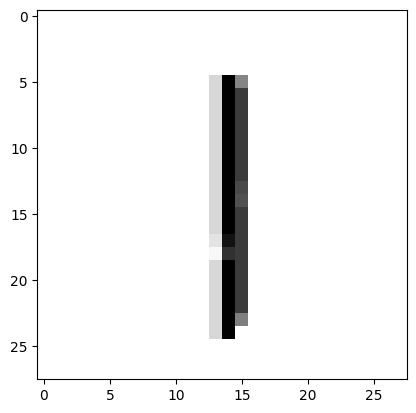

ACTUAL: 9
MODEL OUTPUT: 9


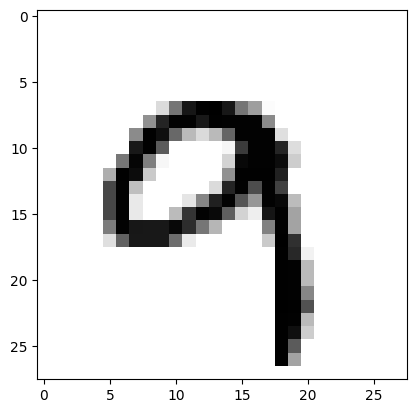

ACTUAL: 8
MODEL OUTPUT: 8


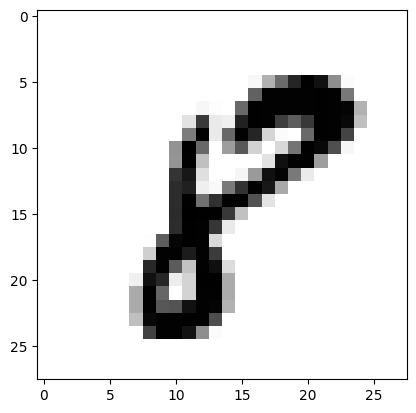

ACTUAL: 1
MODEL OUTPUT: 1


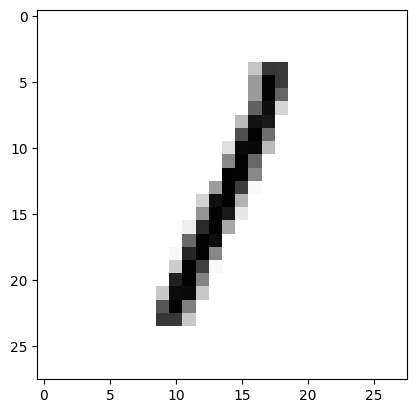

ACTUAL: 8
MODEL OUTPUT: 8


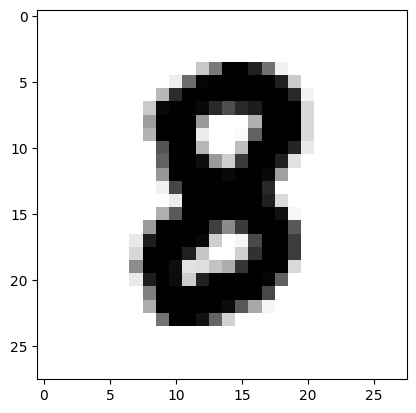

ACTUAL: 8
MODEL OUTPUT: 8


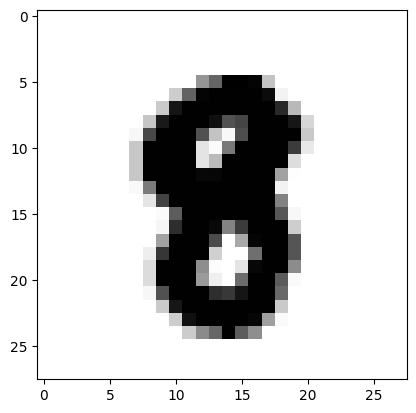

ACTUAL: 4
MODEL OUTPUT: 9


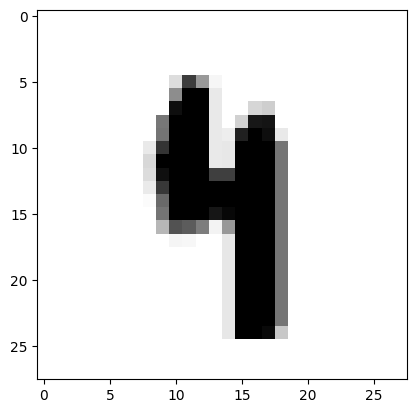

ACTUAL: 3
MODEL OUTPUT: 3


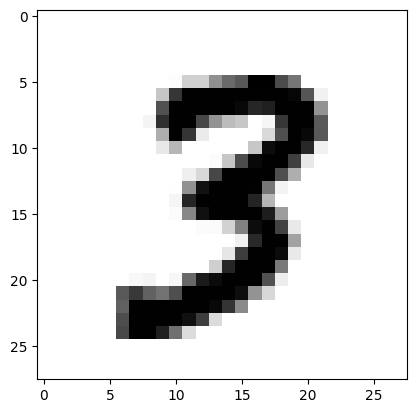

ACTUAL: 5
MODEL OUTPUT: 5


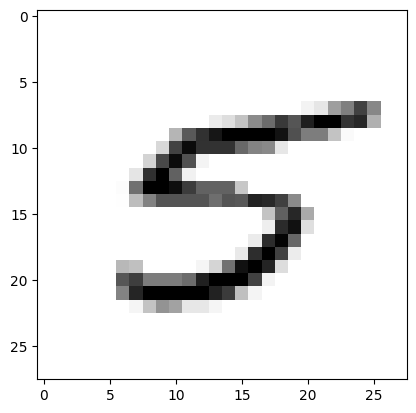

ACTUAL: 9
MODEL OUTPUT: 9


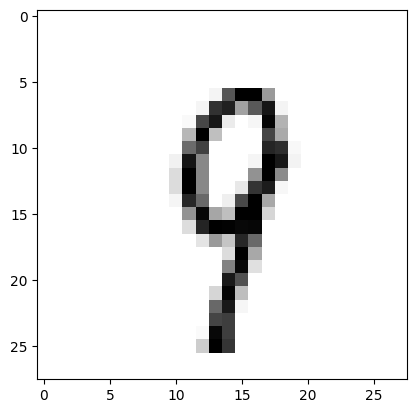

In [8]:
import matplotlib.pyplot as plt
for i in range(32):
    print("ACTUAL:", labels.numpy()[i])
    print("MODEL OUTPUT:", idx.cpu().numpy()[i])
    plt.imshow(inputs.numpy()[i, 0], cmap='gray_r')
    plt.show()